# Credit Risk Analytics

## Objective
The objective of this project is to analyze factors affecting loan approval and build a machine learning model capable of predicting approval outcomes based on applicant characteristics.

## Dataset
Loan Prediction Dataset

## Key Questions
1. Does credit history affect loan approval?
2. Does income influence approval decisions?
3. Are graduates more likely to receive loans?
4. Do married applicants have higher approval rates?
5. Which factors are the strongest predictors of approval?

In [22]:
import pandas as pd

df = pd.read_csv("raw_data.csv")

print("Rows, Columns:", df.shape)

df.head()

Rows, Columns: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [24]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [25]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# Credit History and loan approval.

In [26]:
df.groupby('Credit_History')['Loan_Status'].value_counts()

Credit_History  Loan_Status
0.0             N               82
                Y                7
1.0             Y              378
                N               97
Name: count, dtype: int64

## Insight 1: Impact of Credit History on Loan Approval

Applicants with a credit history (Credit_History = 1) had an approval rate of 79.6%, compared to only 7.9% for applicants without a credit history.

This indicates that credit history is one of the most important factors influencing loan approval decisions.

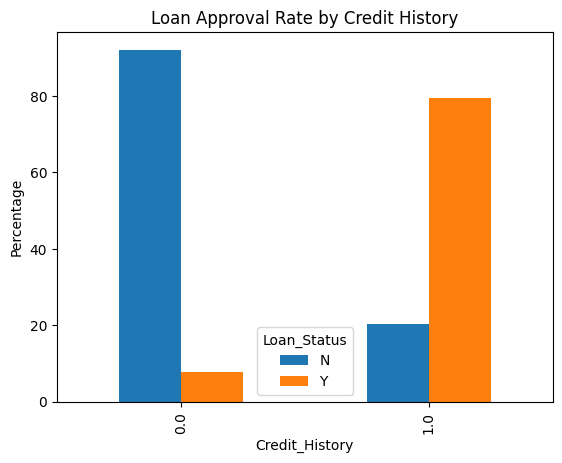

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

approval_rate = pd.crosstab(
    df['Credit_History'],
    df['Loan_Status'],
    normalize='index'
) * 100

approval_rate.plot(kind='bar')

plt.title('Loan Approval Rate by Credit History')
plt.ylabel('Percentage')
plt.show()

# Income vs Approval

In [28]:
df.groupby('Loan_Status')['ApplicantIncome'].mean()

,ApplicantIncome
Loan_Status,
N,5446.078125
Y,5384.068720


## Insight 2: Applicant Income Does Not Strongly Influence Loan Approval

The average income of rejected applicants (5446) was slightly higher than that of approved applicants (5384).

This suggests that income alone is not a major factor in determining loan approval. Other variables such as credit history may have a stronger impact on lending decisions.

# Education vs Approval

In [29]:
pd.crosstab(
    df['Education'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


## Insight 3: Graduates Have Higher Loan Approval Rates

Graduate applicants had a loan approval rate of 70.8%, compared to 61.2% for non-graduate applicants.

This suggests that educational qualification may positively influence loan approval decisions, although the impact is significantly smaller than that of credit history.

# Married vs Approval

In [30]:
pd.crosstab(
    df['Married'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,N,Y
Married,,
No,37.089202,62.910798
Yes,28.391960,71.608040


## Insight 4: Married Applicants Have Higher Approval Rates

Married applicants had a loan approval rate of 71.6%, compared to 62.9% for unmarried applicants.

This may indicate that married applicants are perceived as more financially stable and therefore less risky from a lending perspective.

# Property Area

In [31]:
pd.crosstab(
    df['Property_Area'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,N,Y
Property_Area,,
Rural,38.547486,61.452514
Semiurban,23.175966,76.824034
Urban,34.158416,65.841584


## Insight 5 : Applicants from semi-urban have highest approval rates

Applicants from semi-urban areas had the highest loan approval rate at 76.8%, compared to 65.8% in urban areas and 61.5% in rural areas.

This suggests that applicants from semi-urban regions may have exhibited characteristics associated with lower lending risk in this dataset.

# Loan Amount and Approval

In [32]:
df.groupby('Loan_Status')['LoanAmount'].mean()

,LoanAmount
Loan_Status,
N,151.220994
Y,144.294404


## Insight 6 : Slightly larger loans gets rejected

Rejected applicants requested slightly larger loans on average (151.2) compared to approved applicants (144.3).

This suggests that larger loan amounts may be associated with a higher probability of rejection, although the difference is relatively small compared to the impact of credit history.

# Exploratory Data Analysis Summary

## Key Findings

1. Credit history was the strongest predictor of loan approval. Applicants with a credit history had an approval rate of 79.6%, compared to only 7.9% for those without one.

2. Graduate applicants had a higher approval rate (70.8%) than non-graduates (61.2%).

3. Married applicants were approved more frequently (71.6%) than unmarried applicants (62.9%).

4. Semi-urban applicants exhibited the highest approval rate (76.8%), outperforming both urban and rural applicants.

5. Applicant income showed little influence on approval decisions, indicating that lenders consider factors beyond earnings alone.

6. Rejected applicants requested slightly larger loans on average, suggesting a modest relationship between loan size and approval outcomes.

## Preliminary Conclusion

The analysis indicates that creditworthiness-related factors, particularly credit history, play a much larger role in loan approval decisions than income or loan amount. Demographic factors such as education, marital status, and property area also appear to influence approval rates.